# MinTrace Baseline with Train/Test Split

This notebook demonstrates a complete workflow:
1. Loading TourismSmall data
2. Splitting into Train and Test sets
3. Generating Base Forecasts (AutoARIMA)
4. Reconciling with MinTrace
5. Evaluating Performance (MSE)

In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import MinTrace
# Import evaluate directly
from hierarchicalforecast.evaluation import evaluate
from hierarchicalforecast.utils import HierarchicalPlot
from datasetsforecast.hierarchical import HierarchicalData
from utilsforecast.losses import mse


## 1. Load Data & Split

In [45]:
# Load TourismSmall dataset
Y_df, S_df, tags = HierarchicalData.load('./data', 'TourismSmall')
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
S_df = S_df.reset_index(names="unique_id")

# split train/test sets
Y_test_df  = Y_df.groupby('unique_id').tail(4)
Y_train_df = Y_df.drop(Y_test_df.index)

print("Train size:", len(Y_train_df))
print("Test size:", len(Y_test_df))
display(Y_train_df.head())

Train size: 2848
Test size: 356


,unique_id,ds,y
0,total,1998-03-31,84503
1,total,1998-06-30,65312
2,total,1998-09-30,72753
3,total,1998-12-31,70880
4,total,1999-03-31,86893


## 2. Base Forecasts

In [46]:
# Compute base auto-ARIMA predictions
# Ensure frequency matches dataset (Quarter End 'QE')
fcst = StatsForecast(models=[AutoARIMA(season_length=4), Naive()],
                     freq='QE', n_jobs=-1)

Y_hat_df = fcst.forecast(df=Y_train_df, h=4)
display(Y_hat_df.head())

,unique_id,ds,AutoARIMA,Naive
0,bus,2006-03-31,8918.474609,11547.0
1,bus,2006-06-30,9581.921875,11547.0
2,bus,2006-09-30,11194.672852,11547.0
3,bus,2006-12-31,10678.953125,11547.0
4,hol,2006-03-31,42805.343750,26418.0


## 3. Reconciliation (MinTrace)

In [47]:
# Reconcile the base predictions
reconcilers = [
    MinTrace(method='ols'),
    #MinTrace(method='mint_shrink')
]
hrec = HierarchicalReconciliation(reconcilers=reconcilers)

try:
    Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_train_df,
                              S=S_df.set_index('unique_id'), tags=tags)
except Exception as e:
    print(f"First attempt failed: {e}. Trying with S_df arg...")
    Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_train_df,
                              S=S_df, tags=tags)

display(Y_rec_df.head())

First attempt failed: Check `S_df` columns, 'unique_id' must be in `S_df` columns.. Trying with S_df arg...


C:\Users\MarcellNemeth\AppData\Local\Temp\ipykernel_13020\337561149.py:9: DeprecationWarning: The 'S' parameter is deprecated and will be removed in a future version. Please use 'S_df' instead.
  Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_train_df,
C:\Users\MarcellNemeth\AppData\Local\Temp\ipykernel_13020\337561149.py:13: DeprecationWarning: The 'S' parameter is deprecated and will be removed in a future version. Please use 'S_df' instead.
  Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_train_df,


,unique_id,ds,AutoARIMA,Naive,AutoARIMA/MinTrace_method-ols,Naive/MinTrace_method-ols
0,total,2006-03-31,85909.171875,63392.0,84984.427109,63392.0
1,total,2006-06-30,63981.953125,63392.0,62996.552090,63392.0
2,total,2006-09-30,70983.882812,63392.0,69980.324779,63392.0
3,total,2006-12-31,67429.898438,63392.0,66647.462381,63392.0
4,hol,2006-03-31,42805.343750,26418.0,43479.604848,26418.0


## 4. Evaluation

In [48]:
# Combine reconciled forecasts with test data
# Ensure data types match for merge
Y_rec_df['ds'] = pd.to_datetime(Y_rec_df['ds'])
Y_test_df['ds'] = pd.to_datetime(Y_test_df['ds'])

df = Y_rec_df.merge(Y_test_df, on=['unique_id', 'ds'])

print(f"Merged DataFrame size: {len(df)}")
if len(df) == 0:
    print("WARNING: Empty merge. Checking dates...")
    print("Forecast Dates:", Y_rec_df['ds'].unique())
    print("Test Dates:", Y_test_df['ds'].unique())

# Evaluate using the standalone evaluate function
evaluation_df = evaluate(df=df,
                      tags=tags,
                      metrics=[mse],
                      benchmark="Naive")

display(evaluation_df)

Merged DataFrame size: 356


C:\Users\MarcellNemeth\AppData\Local\Temp\ipykernel_13020\3861967988.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test_df['ds'] = pd.to_datetime(Y_test_df['ds'])


,level,metric,AutoARIMA,Naive,AutoARIMA/MinTrace_method-ols,Naive/MinTrace_method-ols
0,Country,mse-scaled,0.123161,1.0,0.117493,1.0
1,Country/Purpose,mse-scaled,0.171063,1.0,0.126589,1.0
2,Country/Purpose/State,mse-scaled,0.194383,1.0,0.191021,1.0
3,Country/Purpose/State/CityNonCity,mse-scaled,0.170378,1.0,0.198982,1.0
4,Overall,mse-scaled,0.154912,1.0,0.136899,1.0


## 5. Visualization

We use `HierarchicalPlot` to visualize the history, truth (test set), and forecasts (Base + MinTrace).

Plotting models: ['y', 'AutoARIMA', 'Naive/MinTrace_method-ols']


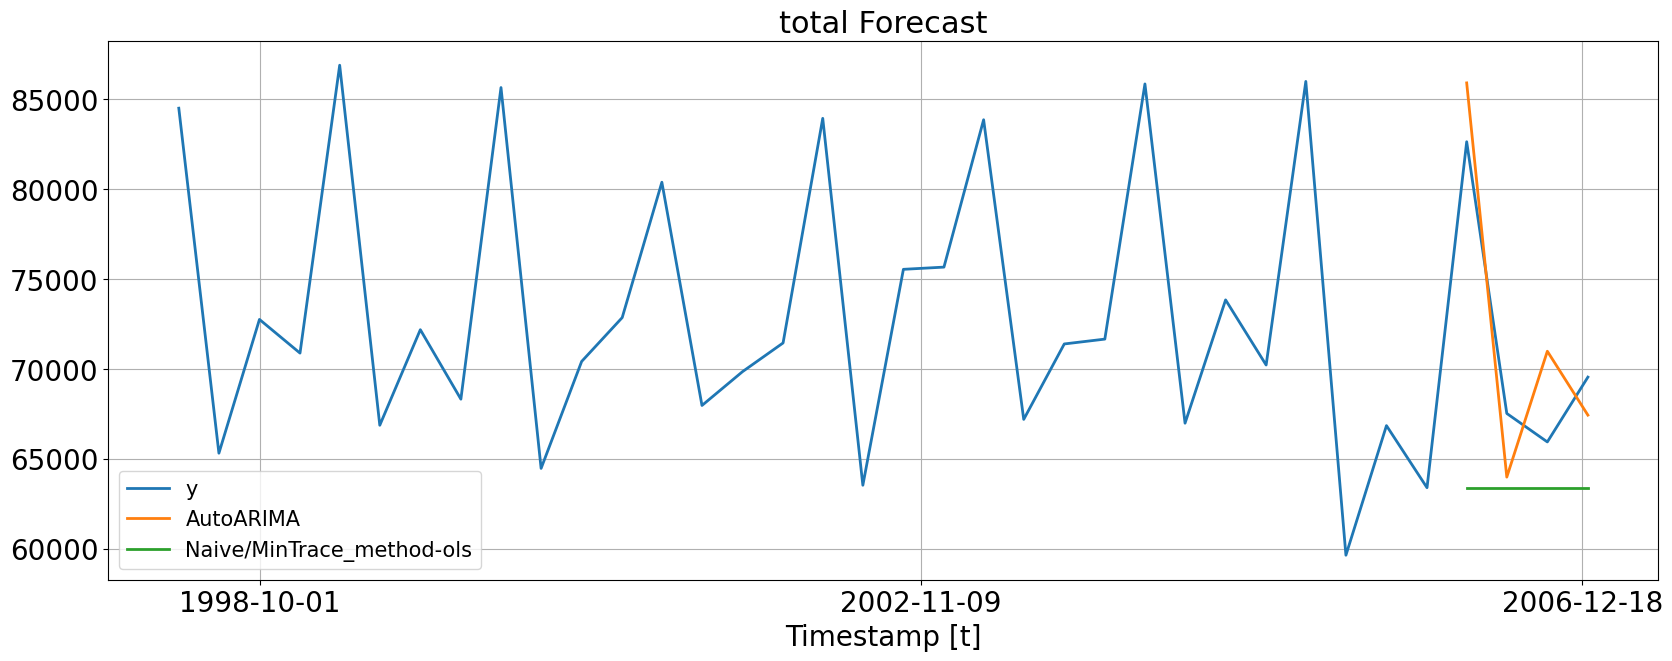

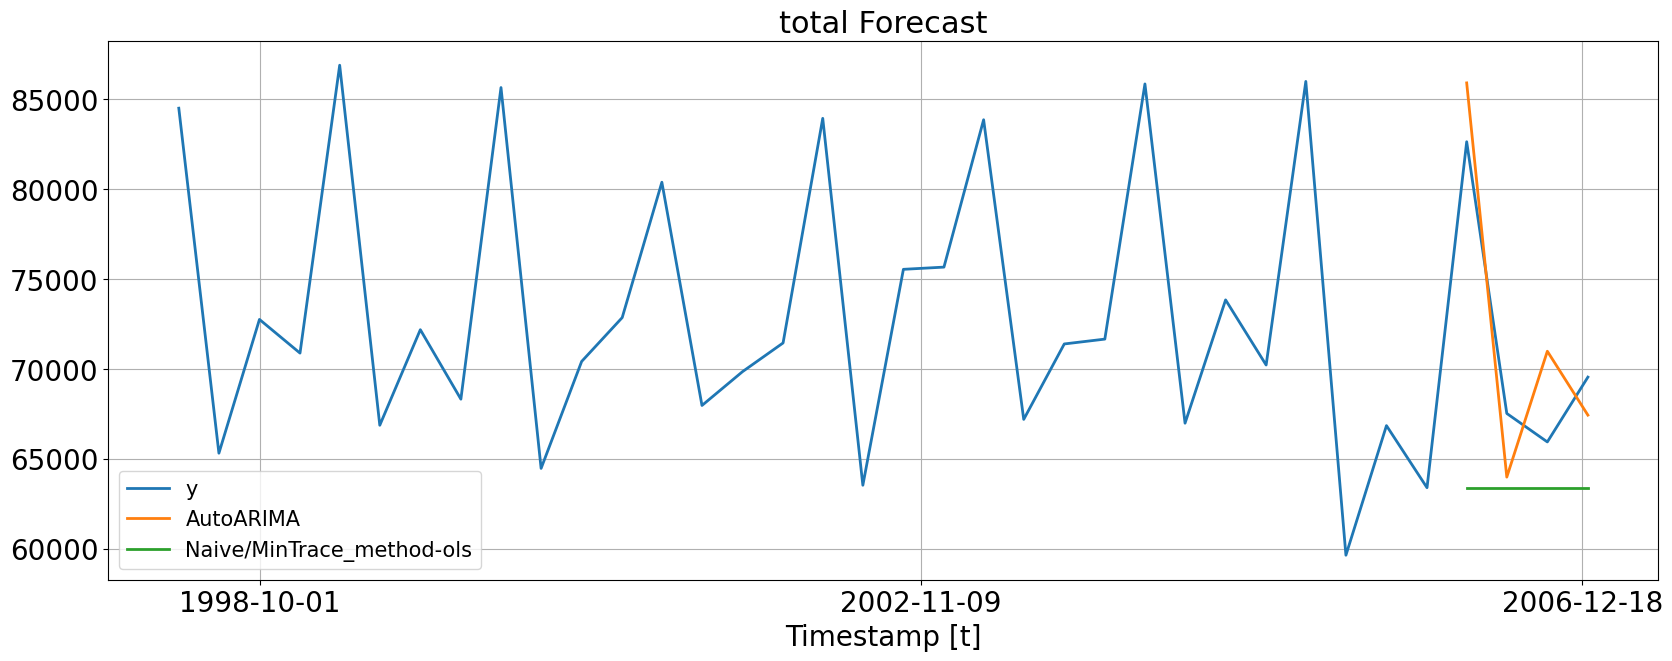

In [49]:
# Prepare DataFrame for plotting
# We combine Training History + Test Set (Truth) + Forecasts
# 1. Get full history (Train + Test) from Y_df
plot_df = Y_df.set_index(['unique_id', 'ds']).copy()

# 2. Join with Forecasts (Y_rec_df), keeping all columns
plot_rec_df = Y_rec_df.set_index(['unique_id', 'ds'])
plot_df = plot_df.join(plot_rec_df, how='outer').reset_index()

# Initialize HierarchicalPlot
# Ensure S_df has unique_id as a column
S_df_plot = S_df.reset_index(names='unique_id') if 'unique_id' not in S_df.columns else S_df

hplot = HierarchicalPlot(S=S_df_plot, tags=tags)

# Plot specific series (e.g., Total aggregate)
# We plot 'y' (History+Truth), 'AutoARIMA' (Base), and 'AutoARIMA/MinTrace_method-mint_shrink' (Reconciled)
models_to_plot = ['y', 'AutoARIMA']
mint_col = [c for c in plot_df.columns if 'MinTrace' in c]
if mint_col:
    models_to_plot.append(mint_col[-1]) # Pick one MintTrace variant to plot

print(f"Plotting models: {models_to_plot}")

# Note: The dataset uses 'total' (lowercase) not 'Total'
hplot.plot_series(
    series='total', 
    Y_df=plot_df, 
    models=models_to_plot
)